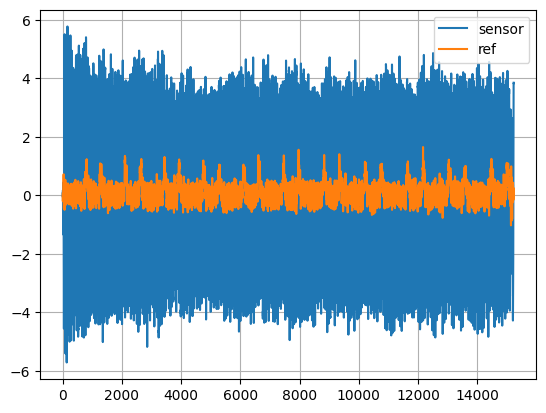

In [1]:
import numpy as np
import pandas as pd
import logging
from pyproj import Proj
from scipy.interpolate import PchipInterpolator
import math
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from matplotlib.ticker import MultipleLocator

logger = logging.getLogger(__name__)

# -----------------------------------------------------------
# 전역(글로벌) Proj 객체: UTM zone 52N (EPSG:32652)
# -----------------------------------------------------------
_proj_utm52 = Proj("epsg:32652")


def load_and_preprocess_csv_v1(
    file_path_sensor,
    file_path_ref,
    skiprows=100,
    skipfooter=100,
    flag=False,
    zone=52,
    expected_total_deg=0,
    window_size=200,
    time_tolerance="10ms",   # 필요시 조절
):
    # -----------------------------
    # 1. CSV 로드
    # -----------------------------
    df_sensor = pd.read_csv(
        file_path_sensor,
        skiprows=skiprows,
        skipfooter=skipfooter,
        na_values=["", "nan", "NaN"],
        engine="python",
    ).fillna(0)

    df_ref = pd.read_csv(
        file_path_ref,
        skiprows=skiprows,
        skipfooter=skipfooter,
        na_values=["", "nan", "NaN"],
        engine="python",
    ).fillna(0)

    columns = [
        "Time",
        "Accelerometer x",
        "Accelerometer y",
        "Accelerometer z",
        "Gyroscope x",
        "Gyroscope y",
        "Gyroscope z",
        "Magnetometer x",
        "Magnetometer y",
        "Magnetometer z",
        "Orientation x",
        "Orientation y",
        "Orientation z",
        "Pressure",
        "Latitude",
        "Longitude",
        "Altitude",
        "Speed_GPS",
    ]

    df_sensor.columns = columns
    df_ref.columns = columns

    # -----------------------------
    # 2. Time datetime 변환
    # -----------------------------
    df_sensor["Time"] = pd.to_datetime(df_sensor["Time"], errors="coerce")
    df_ref["Time"] = pd.to_datetime(df_ref["Time"], errors="coerce")

    # Time 파싱 실패 행 제거
    df_sensor = df_sensor.dropna(subset=["Time"]).copy()
    df_ref = df_ref.dropna(subset=["Time"]).copy()

    # 시간순 정렬
    df_sensor = df_sensor.sort_values("Time").reset_index(drop=True)
    df_ref = df_ref.sort_values("Time").reset_index(drop=True)

    # -----------------------------
    # 3. 공통 시간 구간 계산
    #    시작은 느린 쪽, 끝은 빠른 쪽
    # -----------------------------
    start_time = max(df_sensor["Time"].iloc[0], df_ref["Time"].iloc[0])
    end_time = min(df_sensor["Time"].iloc[-1], df_ref["Time"].iloc[-1])

    if start_time >= end_time:
        raise ValueError("두 데이터의 공통 시간 구간이 없습니다.")

    # 공통 구간만 남기기
    df_sensor = df_sensor[(df_sensor["Time"] >= start_time) & (df_sensor["Time"] <= end_time)].copy()
    df_ref = df_ref[(df_ref["Time"] >= start_time) & (df_ref["Time"] <= end_time)].copy()

    df_sensor = df_sensor.sort_values("Time").reset_index(drop=True)
    df_ref = df_ref.sort_values("Time").reset_index(drop=True)

    # -----------------------------
    # 4. ref에서 가져올 컬럼만 추출 후 접두어 부여
    #    Acc, Gyro, Orientation만 추가
    # -----------------------------
    ref_cols = [
        "Time",
        "Accelerometer x",
        "Accelerometer y",
        "Accelerometer z",
        "Gyroscope x",
        "Gyroscope y",
        "Gyroscope z",
        "Orientation x",
        "Orientation y",
        "Orientation z",
    ]

    df_ref_small = df_ref[ref_cols].copy()

    rename_dict = {
        "Accelerometer x": "ref_Accelerometer x",
        "Accelerometer y": "ref_Accelerometer y",
        "Accelerometer z": "ref_Accelerometer z",
        "Gyroscope x": "ref_Gyroscope x",
        "Gyroscope y": "ref_Gyroscope y",
        "Gyroscope z": "ref_Gyroscope z",
        "Orientation x": "ref_Orientation x",
        "Orientation y": "ref_Orientation y",
        "Orientation z": "ref_Orientation z",
    }
    df_ref_small = df_ref_small.rename(columns=rename_dict)

    # -----------------------------
    # 5. Time 기준 가장 가까운 샘플끼리 merge
    #    완전히 같은 timestamp가 아닐 수 있으므로 merge_asof 사용
    # -----------------------------
    df_merged = pd.merge_asof(
        df_sensor.sort_values("Time"),
        df_ref_small.sort_values("Time"),
        on="Time",
        direction="nearest",
        tolerance=pd.Timedelta(time_tolerance),
    )

    # # tolerance 안에 매칭이 안 된 행 제거
    # ref_added_cols = list(rename_dict.values())
    # df_merged = df_merged.dropna(subset=ref_added_cols).reset_index(drop=True)

    # logger.info(f"sensor start: {df_sensor['Time'].iloc[0]}, end: {df_sensor['Time'].iloc[-1]}")
    # logger.info(f"ref start:    {df_ref['Time'].iloc[0]}, end: {df_ref['Time'].iloc[-1]}")
    # logger.info(f"common start: {start_time}, common end: {end_time}")
    # logger.info(f"merged length: {len(df_merged)}")

    return df_merged


f1p = 'data/tester1/learn_swing/swing_left01.csv'
f2p = 'data/tester1/learn_swing/swing_left01_ref.csv'

good_df = load_and_preprocess_csv_v1(f1p, f2p)

plt.plot(good_df['Gyroscope z'], label='sensor')
plt.plot(good_df['ref_Gyroscope z'], label='ref')
plt.grid()
plt.legend()
plt.show()





In [2]:
def load_and_preprocess_csv_v2(
    file_path_sensor,
    file_path_ref,
    skiprows=100,
    skipfooter=100,
    flag=True,
    zone=52,
    expected_total_deg=0,
    window_size=200,
    time_tolerance="50ms",
):
    # -----------------------------
    # 1. CSV 로드
    # -----------------------------
    df_sensor = pd.read_csv(
        file_path_sensor,
        skiprows=skiprows,
        skipfooter=skipfooter,
        na_values=["", "nan", "NaN"],
        engine="python",
    ).fillna(0)

    df_ref = pd.read_csv(
        file_path_ref,
        skiprows=skiprows,
        skipfooter=skipfooter,
        na_values=["", "nan", "NaN"],
        engine="python",
    ).fillna(0)

    columns = [
        "Time",
        "Accelerometer x",
        "Accelerometer y",
        "Accelerometer z",
        "Gyroscope x",
        "Gyroscope y",
        "Gyroscope z",
        "Magnetometer x",
        "Magnetometer y",
        "Magnetometer z",
        "Orientation x",
        "Orientation y",
        "Orientation z",
        "Pressure",
        "Latitude",
        "Longitude",
        "Altitude",
        "Speed_GPS",
    ]

    df_sensor.columns = columns
    df_ref.columns = columns

    # -----------------------------
    # 2. Time datetime 변환
    # -----------------------------
    df_sensor["Time"] = pd.to_datetime(df_sensor["Time"], errors="coerce")
    df_ref["Time"] = pd.to_datetime(df_ref["Time"], errors="coerce")

    df_sensor = df_sensor.dropna(subset=["Time"]).copy()
    df_ref = df_ref.dropna(subset=["Time"]).copy()

    df_sensor = df_sensor.sort_values("Time").reset_index(drop=True)
    df_ref = df_ref.sort_values("Time").reset_index(drop=True)

    # -----------------------------
    # 3. 공통 시간 구간 계산
    # -----------------------------
    start_time = max(df_sensor["Time"].iloc[0], df_ref["Time"].iloc[0])
    end_time = min(df_sensor["Time"].iloc[-1], df_ref["Time"].iloc[-1])

    if start_time >= end_time:
        raise ValueError("두 데이터의 공통 시간 구간이 없습니다.")

    df_sensor = df_sensor[
        (df_sensor["Time"] >= start_time) & (df_sensor["Time"] <= end_time)
    ].copy()
    df_ref = df_ref[
        (df_ref["Time"] >= start_time) & (df_ref["Time"] <= end_time)
    ].copy()

    df_sensor = df_sensor.sort_values("Time").reset_index(drop=True)
    df_ref = df_ref.sort_values("Time").reset_index(drop=True)

    # -----------------------------
    # 4. ref에서 가져올 컬럼만 추출 후 접두어 부여
    #    Acc, Gyro, Orientation + GPS 추가
    # -----------------------------
    ref_cols = [
        "Time",
        "Accelerometer x",
        "Accelerometer y",
        "Accelerometer z",
        "Gyroscope x",
        "Gyroscope y",
        "Gyroscope z",
        "Orientation x",
        "Orientation y",
        "Orientation z",
        "Latitude",
        "Longitude",
        "Altitude",
        "Speed_GPS",
    ]

    df_ref_small = df_ref[ref_cols].copy()

    rename_dict = {
        "Accelerometer x": "ref_Accelerometer x",
        "Accelerometer y": "ref_Accelerometer y",
        "Accelerometer z": "ref_Accelerometer z",
        "Gyroscope x": "ref_Gyroscope x",
        "Gyroscope y": "ref_Gyroscope y",
        "Gyroscope z": "ref_Gyroscope z",
        "Orientation x": "ref_Orientation x",
        "Orientation y": "ref_Orientation y",
        "Orientation z": "ref_Orientation z",
        "Latitude": "ref_Latitude",
        "Longitude": "ref_Longitude",
        "Altitude": "ref_Altitude",
        "Speed_GPS": "ref_Speed_GPS",
    }
    df_ref_small = df_ref_small.rename(columns=rename_dict)

    # -----------------------------
    # 5. Time 기준 가장 가까운 샘플끼리 merge
    # -----------------------------
    df = pd.merge_asof(
        df_sensor.sort_values("Time"),
        df_ref_small.sort_values("Time"),
        on="Time",
        direction="nearest",
        tolerance=pd.Timedelta(time_tolerance),
    )

    # ref가 매칭 안 된 행 제거
    df = df.dropna(subset=["ref_Latitude", "ref_Longitude"]).reset_index(drop=True)

    # 필요하면 sensor GPS 대신 ref GPS를 메인 GPS로 덮어쓰기
    df["Latitude"] = df["ref_Latitude"]
    df["Longitude"] = df["ref_Longitude"]
    df["Altitude"] = df["ref_Altitude"]
    df["Speed_GPS"] = df["ref_Speed_GPS"]

    df["Time"] = pd.to_datetime(df["Time"], format="%Y-%m-%d %H:%M:%S.%f", errors="coerce")
    start_dt = df["Time"].iloc[0]
    df["Elapsed Time"] = (df["Time"] - start_dt).dt.total_seconds()

    df["Acc_Norm"] = np.linalg.norm(
        df[["Accelerometer x", "Accelerometer y", "Accelerometer z"]].values, axis=1
    )
    df["Gyro_Norm"] = np.linalg.norm(
        df[["Gyroscope x", "Gyroscope y", "Gyroscope z"]].values, axis=1
    )

    # -------------------------------------------------------
    # 이제 GPS는 ref 기준으로 계산
    # -------------------------------------------------------
    valid_gps_mask = (
        df["ref_Latitude"].notna()
        & df["ref_Longitude"].notna()
        & (df["ref_Latitude"].astype(str).str.strip() != "")
        & (df["ref_Longitude"].astype(str).str.strip() != "")
    )

    valid_lat = pd.to_numeric(df.loc[valid_gps_mask, "ref_Latitude"], errors="coerce")
    valid_lon = pd.to_numeric(df.loc[valid_gps_mask, "ref_Longitude"], errors="coerce")

    final_mask = valid_lat.notna() & valid_lon.notna()
    valid_lat = valid_lat[final_mask].values
    valid_lon = valid_lon[final_mask].values

    if len(valid_lat) == 0:
        raise ValueError("유효한 ref GPS 데이터가 없습니다.")

    proj_enu = Proj(proj="utm", zone=zone, ellps="WGS84", south=False)
    e0, n0 = proj_enu(valid_lon[0], valid_lat[0])
    e_valid, n_valid = proj_enu(valid_lon, valid_lat)
    e_valid -= e0
    n_valid -= n0

    df["E"], df["N"] = np.nan, np.nan
    valid_idx = df.index[valid_gps_mask][final_mask]
    df.loc[valid_idx, "E"] = e_valid
    df.loc[valid_idx, "N"] = n_valid

    e = df["E"][df["E"].notna()].values
    n = df["N"][df["N"].notna()].values

    delta_e = np.diff(e)
    delta_n = np.diff(n)
    step = np.hypot(delta_e, delta_n)

    stop_mask = step < 0.05
    mask = ~stop_mask
    gps_idx_all = np.arange(1, len(e))
    bad_idx = gps_idx_all[~mask]

    print(f"총 GPS 샘플: {len(e)}, 이상치 GPS 샘플: {len(bad_idx)}")

    # -------------------------------------------------------
    # (4) 센서데이터 블록 drop (1Hz GPS → 50Hz 센서)
    # -------------------------------------------------------
    drop_idx = []
    for gi in bad_idx:
        start = gi * 50
        end = (gi + 1) * 50
        drop_idx.extend(range(start, min(end, len(df))))
    df = df.drop(drop_idx).reset_index(drop=True)

    # --- drop 이후 다시 ref GPS 기준 ENU 계산 ---
    valid_gps_mask = (
        df["ref_Latitude"].notna()
        & df["ref_Longitude"].notna()
        & (df["ref_Latitude"].astype(str).str.strip() != "")
        & (df["ref_Longitude"].astype(str).str.strip() != "")
    )

    valid_lat = pd.to_numeric(df.loc[valid_gps_mask, "ref_Latitude"], errors="coerce")
    valid_lon = pd.to_numeric(df.loc[valid_gps_mask, "ref_Longitude"], errors="coerce")

    final_mask = valid_lat.notna() & valid_lon.notna()
    valid_lat = valid_lat[final_mask].values
    valid_lon = valid_lon[final_mask].values

    if len(valid_lat) < 2:
        raise ValueError("유효 ref GPS가 drop 이후 2개 미만으로 남음")

    proj_enu = Proj(proj="utm", zone=zone, ellps="WGS84", south=False)
    e0, n0 = proj_enu(valid_lon[0], valid_lat[0])
    e_valid, n_valid = proj_enu(valid_lon, valid_lat)
    e, n = e_valid - e0, n_valid - n0

    dx0, dy0 = e[1] - e[0], n[1] - n[0]
    theta0 = math.atan2(dy0, dx0)
    R0 = np.array([
        [math.cos(-theta0), -math.sin(-theta0)],
        [math.sin(-theta0),  math.cos(-theta0)],
    ])
    coords = np.vstack([e - e[0], n - n[0]])
    rotated = R0 @ coords
    e_corr, n_corr = rotated[0], rotated[1]

    delta_e = np.diff(e_corr)
    delta_n = np.diff(n_corr)

    disp_1hz = np.hypot(delta_e, delta_n)
    heading_1hz = np.arctan2(delta_n, delta_e)

    N = len(heading_1hz)
    t = np.arange(N, dtype=float)
    t_new = np.linspace(0.0, N - 1, (N - 1) * 10 + 1)

    heading_unwrap = np.unwrap(heading_1hz)

    p_disp = PchipInterpolator(t, disp_1hz)
    p_head = PchipInterpolator(t, heading_unwrap)

    disp_10Hz = p_disp(t_new)
    head_10Hz = p_head(t_new)
    dh_10Hz = np.diff(head_10Hz)
    dh_1s_10Hz = np.convolve(dh_10Hz, np.ones(10), mode="valid")

    disp_10Hz = disp_10Hz[1:]
    head_10Hz = head_10Hz[1:]

    v_10Hz = disp_10Hz.copy()

    fs = 50.0
    dt = 1.0 / fs

    gx = df["ref_Gyroscope x"].to_numpy(dtype=float, copy=True)
    gy = df["ref_Gyroscope y"].to_numpy(dtype=float, copy=True)
    gz = df["ref_Gyroscope z"].to_numpy(dtype=float, copy=True)

    qx = df["ref_Orientation x"].to_numpy(dtype=float, copy=True)
    qy = df["ref_Orientation y"].to_numpy(dtype=float, copy=True)
    qz = df["ref_Orientation z"].to_numpy(dtype=float, copy=True)

    qw_sq = 1.0 - (qx**2 + qy**2 + qz**2)
    qw_sq = np.clip(qw_sq, 0.0, None)
    qw = np.sqrt(qw_sq)

    for i in range(1, len(qw)):
        dot = (
            qw[i-1] * qw[i]
            + qx[i-1] * qx[i]
            + qy[i-1] * qy[i]
            + qz[i-1] * qz[i]
        )
        if dot < 0:
            qw[i] = -qw[i]
            qx[i] = -qx[i]
            qy[i] = -qy[i]
            qz[i] = -qz[i]

    pitch = np.arctan2(
        2.0 * (qw * qx + qy * qz),
        1.0 - 2.0 * (qx * qx + qy * qy)
    )

    gyro_corr = np.zeros((len(gx), 3))

    for i in range(len(gx)):
        c = np.cos(pitch[i])
        s = np.sin(pitch[i])

        R_inv_pitch = np.array([
            [1, 0, 0],
            [0, c, -s],
            [0, s,  c]
        ])

        g = np.array([gx[i], gy[i], gz[i]])
        gyro_corr[i] = R_inv_pitch @ g

    gx_corr = gyro_corr[:, 0]
    gy_corr = gyro_corr[:, 1]
    gz_corr = gyro_corr[:, 2]

    theta_z = np.cumsum(gz_corr) * dt
    theta_z_deg = np.degrees(theta_z)

    dh_50Hz = np.diff(theta_z)

    stride = 5
    sensor_cols = [
        "Accelerometer x",
        "Accelerometer y",
        "Accelerometer z",
        "Gyroscope x",
        "Gyroscope y",
        "Gyroscope z",
        "Acc_Norm",
        "Gyro_Norm",
    ]

    values = df[sensor_cols].to_numpy()
    N, num_features = values.shape

    if stride == 1:
        windows = sliding_window_view(values, (window_size, num_features))
        X = windows[:, 0, :, :]
    else:
        X_list = []
        for i in range(0, N - window_size + 1, stride):
            X_list.append(values[i:i + window_size])
        X = np.stack(X_list, axis=0)

    Y_v = []
    offsets = [0, 10, 20, 30]

    for i in range(len(v_10Hz) - max(offsets)):
        Y_v.append(
            v_10Hz[i + offsets[0]]
            + v_10Hz[i + offsets[1]]
            + v_10Hz[i + offsets[2]]
            + v_10Hz[i + offsets[3]]
        )

    Y_dh = []
    for i in range(0, len(dh_50Hz) - window_size + 1, stride):
        dh_sum = np.sum(dh_50Hz[i:i + window_size])
        if np.abs(np.degrees(dh_sum)) < 3:
            dh_sum = 0
        Y_dh.append(dh_sum)

    min_len = min(len(X), len(Y_v), len(Y_dh))
    X = X[:min_len]
    Y_v = Y_v[:min_len]
    Y_dh = Y_dh[:min_len]

    Y = np.stack([Y_v, Y_dh], axis=1)

    return df, X, Y

총 GPS 샘플: 287, 이상치 GPS 샘플: 1


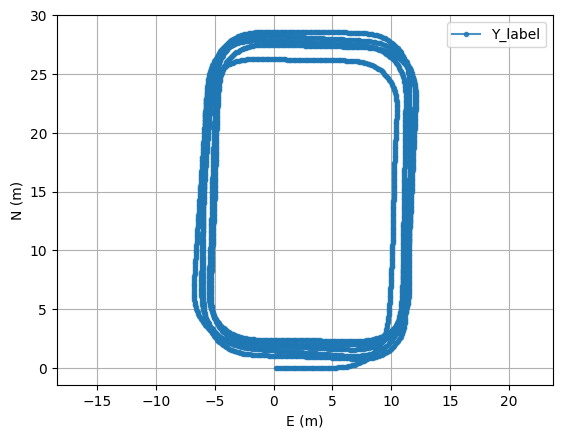

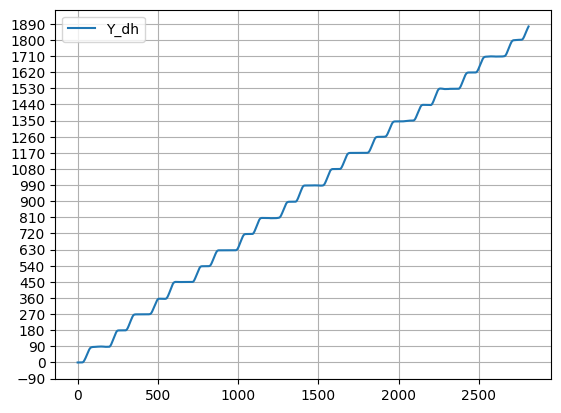

In [4]:
f1p = 'data/tester1/learn_swing/swing_left01.csv'
f2p = 'data/tester1/learn_swing/swing_left01_ref.csv'

good_df, X, Y = load_and_preprocess_csv_v2(f1p, f2p, 1000, 100, True)

window_size = 200

y_e = []
y_n = []
dx = 0.0
dy = 0.0
heading = 0

stride = 5


for v, h in zip(Y[:, 0], Y[:, 1]):
    heading += h * (stride / window_size)
    dx += (v * (stride / window_size)) * np.cos(heading)
    dy += (v * (stride / window_size)) * np.sin(heading)
    y_e.append(dx)
    y_n.append(dy)


#plt.plot(e, n, ".-", label="Y_true")
plt.plot(y_e, y_n, ".-", label="Y_label", alpha=0.8)
plt.xlabel("E (m)")
plt.ylabel("N (m)")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()

plt.plot(
    np.cumsum(np.degrees(Y[:, 1])) * (stride / window_size), label="Y_dh"
)
plt.gca().yaxis.set_major_locator(MultipleLocator(90))
plt.grid()
plt.legend()
plt.show()